## **Timeseries Market Trend Extraction Model**

In [11]:
import sys
assert sys.version_info >= (3, 5)

# Scikit-Learn ≥0.20 is required
import sklearn
assert sklearn.__version__ >= "0.20"

# Common imports
import numpy as np
import os
import pandas as pd
import seaborn as sns

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [12]:
import os
import sys

PROJECT_ROOT = os.path.abspath("..")
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from pipeline.feature_pipeline import PROCESSED_DATA_FILE

current_working_dir = os.getcwd()

if os.path.basename(current_working_dir) == "layers":
    project_root = os.path.abspath(os.path.join(current_working_dir, ".."))
else:
    project_root = current_working_dir

if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Project root added to sys.path: {project_root}")

print(f"Project root added to sys.path: {project_root}")

DATA_DIR = os.path.join(project_root, "data")
PROCESSED_DATA_FILE = os.path.join(DATA_DIR, "market_features.parquet")

try:
    market_data_df = pd.read_parquet(PROCESSED_DATA_FILE)
    print(F"Successfully loaded processed data from {PROCESSED_DATA_FILE}")
except FileNotFoundError:
    print(f"Processed data file not found at {PROCESSED_DATA_FILE}")
    print("Please ensure the feature pipeline in 'pipeline/feature_pipeline.py' has been added to generate the data.")
    market_data_df = pd.DataFrame()

print(market_data_df.head())

Project root added to sys.path: /Users/raoabdul/Documents/Development/Trading-Bot-Algo
Project root added to sys.path: /Users/raoabdul/Documents/Development/Trading-Bot-Algo
Successfully loaded processed data from /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_features.parquet
                   datetime       close        high         low        open  \
0 2026-01-12 14:43:00+00:00  257.140015  257.290192  256.799988  256.954987   
1 2026-01-12 14:44:00+00:00  257.549988  257.549988  257.010010  257.125000   
2 2026-01-12 14:45:00+00:00  257.774994  257.785004  257.750000  257.750000   
3 2026-01-12 14:46:00+00:00  258.200012  258.304993  257.760010  257.880005   
4 2026-01-12 14:47:00+00:00  258.109985  258.220001  257.970001  258.200012   

   volume  log_return  simple_return  rolling_mean  rolling_std  \
0  101223    0.000720       0.000720    258.072235     0.892677   
1  132336    0.001593       0.001594    257.935449     0.805287   
2  173876    0.000873     

In [13]:
print(market_data_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 377 entries, 0 to 376
Data columns (total 20 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   datetime            377 non-null    datetime64[ns, UTC]
 1   close               377 non-null    float64            
 2   high                377 non-null    float64            
 3   low                 377 non-null    float64            
 4   open                377 non-null    float64            
 5   volume              377 non-null    int64              
 6   log_return          377 non-null    float64            
 7   simple_return       377 non-null    float64            
 8   rolling_mean        377 non-null    float64            
 9   rolling_std         377 non-null    float64            
 10  rolling_zscore      377 non-null    float64            
 11  rolling_volatility  376 non-null    float64            
 12  price_range         377 non-null    

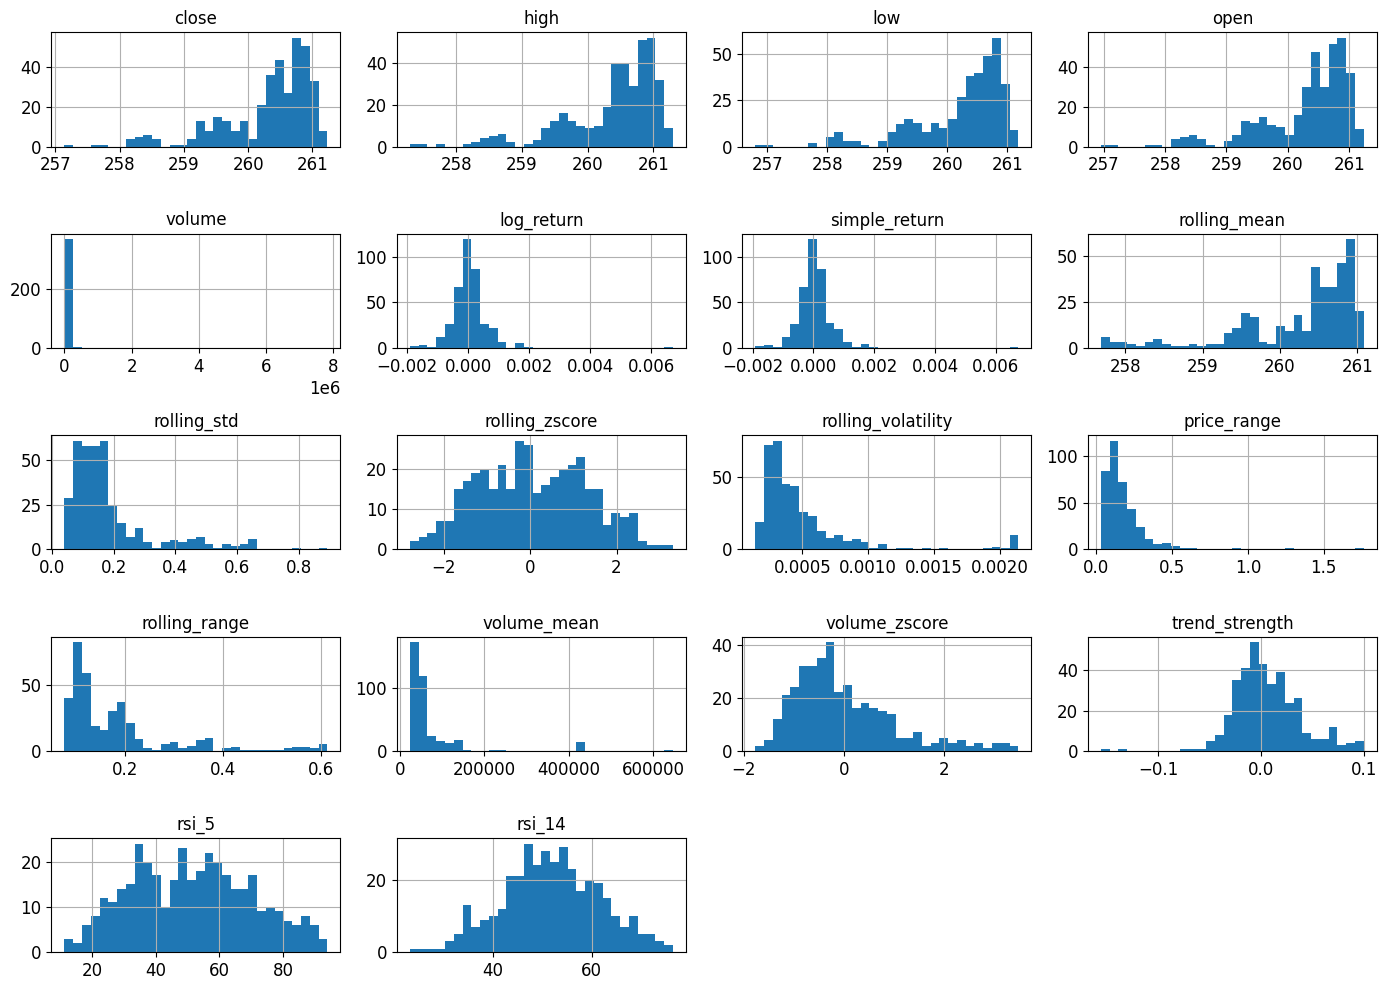

In [14]:
numeric_only_df = market_data_df.select_dtypes(include=np.number)
numeric_only_df.hist(figsize=(14,10), bins=30)
plt.tight_layout()
plt.show()

* Returns (`log_return`, `simple_return`): These distributions are tightly centered around zero, confirming that small price changes are much more common than large ones

* Z-Scores (`rolling_zscore`, `volume_zscore`): These are also centered near zero, which is expected by their definition. They help normalize features and identify periods where price or volume deviates significantly from its recent average

* Volatility & Range (`rolling_std`, `price_range`): These features show a right-skewed distribution, indicating that periods of low volatility are common, punctuated by less frequent but significant spikes in volatility

* Price Features (`close`, `rolling_mean`): The distribution of these features reflects the price movement over the dataset's time period rather than a standard statistical distribution

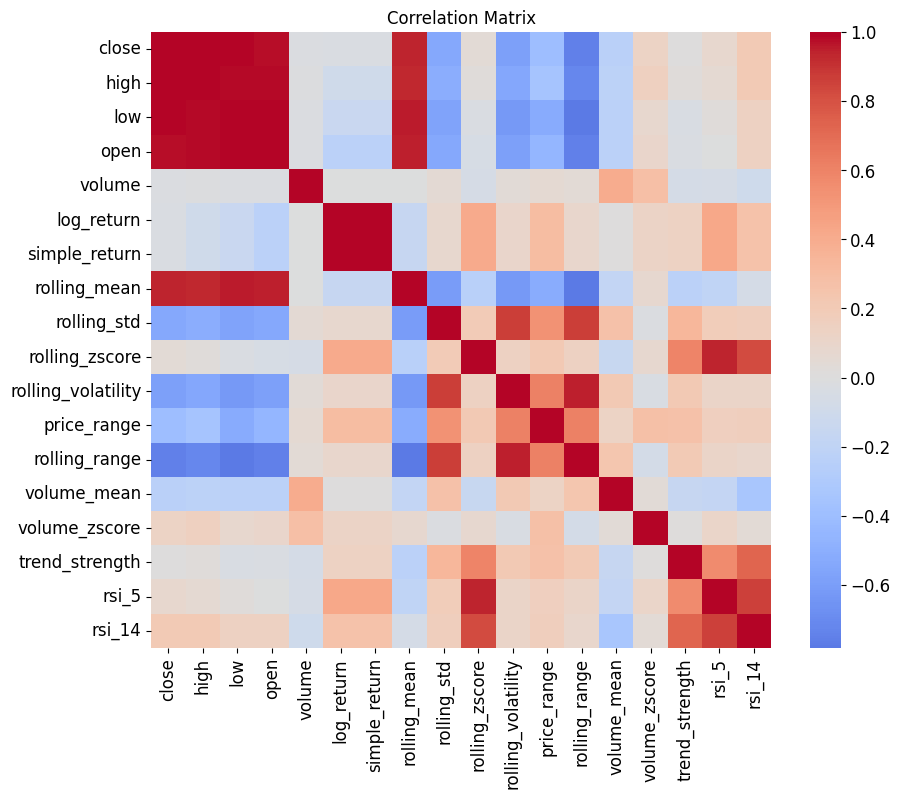

In [15]:
# Correlation matrix
corr = market_data_df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Matrix")
plt.show()

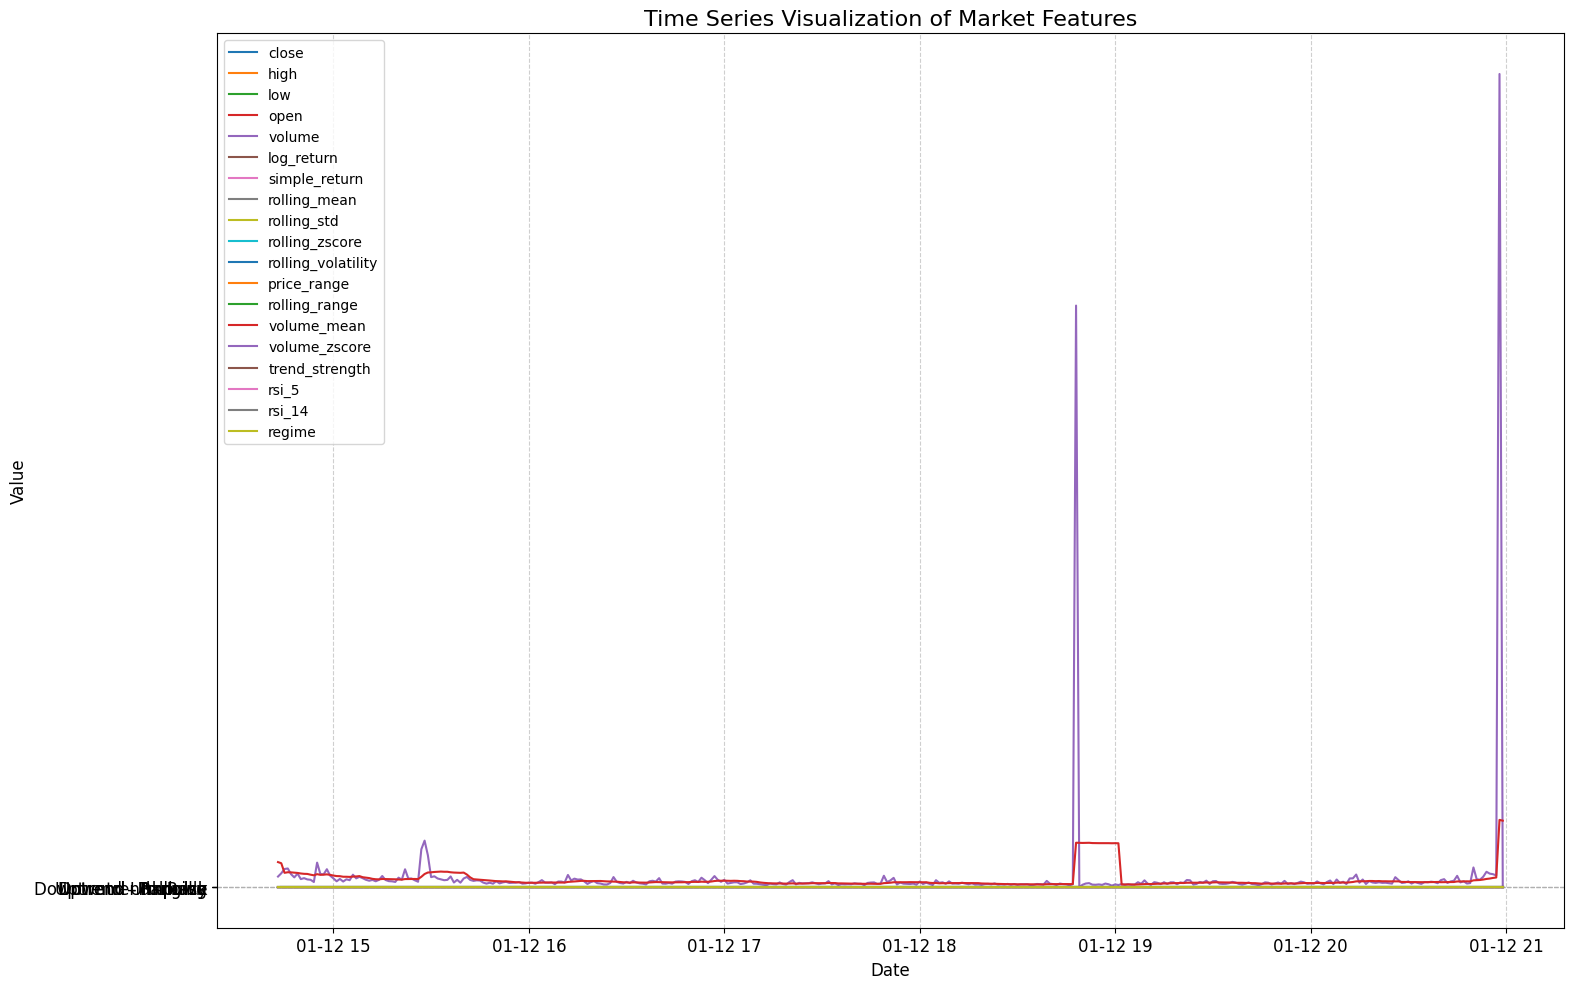

In [16]:
# Assuming market_data_df is your DataFrame and it's already loaded.
# For example:
# market_data_df = pd.read_parquet('path/to/market_features.parquet')
 
# It's good practice to work with a copy if you don't want to modify the original DataFrame
# Set 'datetime' as the index for easy time series plotting
df_for_plotting = market_data_df.set_index('datetime').copy()
    
# Identify columns to plot (all columns except 'datetime', which is now the index)
# All other columns are assumed to be numeric based on previous context
columns_to_plot = [col for col in df_for_plotting.columns]
    
# Create the plot
plt.figure(figsize=(18, 10)) # Adjust figure size as needed for better readability

for column in columns_to_plot:
    plt.plot(df_for_plotting.index, df_for_plotting[column], label=column)

plt.title('Time Series Visualization of Market Features', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Value', fontsize=12)
plt.legend(loc='upper left', fontsize=10) # Place legend outside to prevent overlap
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(rect=[0, 0, 0.88, 1]) # Adjust layout to make space for the legend
plt.show()

## **Notes and Model Evaluation**

* Returns (`log_return`, `simple_return`)
     * Expected Outcome: To normalize price changes and create a series centered
       around zero with a near-normal distribution. The expectation is that small
       changes are frequent, and large changes are rare.
     * What You Found: Your notes confirm they are "tightly centered around zero."
       This is a perfect match and validates this part of the data processing.

   * Z-Scores (`rolling_zscore`, `volume_zscore`)
     * Expected Outcome: To measure how far the current price or volume is from
       its recent average, in units of standard deviations. This normalizes the
       data, making "unusual" events (e.g., a z-score of > 2) easy to spot.
     * What You Found: You correctly noted they are "centered near zero." This is
       the expected behavior and shows the normalization is working.

   * Volatility & Range (`rolling_std`, `rolling_volatility`, `price_range`)
     * Expected Outcome: To quantify the magnitude of price swings. We expect
       these metrics to show periods of calm (low values) punctuated by brief,
       sharp spikes (high values). This should result in a "right-skewed"
       distribution.
     * What You Found: Your analysis of a "right-skewed distribution" where "low
       volatility is common, punctuated by... spikes" is spot-on. This confirms
       you are successfully capturing the classic behavior of market volatility.

   * Trend (`trend_strength`)
     * Expected Outcome: To give a direction and velocity to the price movement.
       It should be positive in uptrends, negative in downtrends, and hover around
       zero in sideways markets.
     * What You Found: While not in your notes, your time series plot would be the
       key here. You should be able to visually see trend_strength rising during
       rallies and falling during declines, confirming its purpose.

Here are key correlations and how they help you build a model to predict the market's nature:

* High Correlation: Volatility Metrics (`rolling_std`, `rolling_volatility`, `price_range`)
    * What it means: These features all measure the same thing: market volatility. When one is high, the others are likely high too.
    * How it helps: A spike in these metrics is a very strong, reliable signal that the market has entered a "High Volatility" regime. This state is often a precursor to a new trend forming or can indicate a "choppy" and unpredictable market to avoid. In your model, you could use a rule like if rolling_volatility > threshold, then regime = 'High Volatility'
    
* Correlation: Volume (`volume_zscore`) and Trend (`trend_strength`)
  * What it means: A trend that occurs on high volume is considered more significant and is more likely to continue.
  * How it helps: This is a powerful "confirmation" signal. A model can be built to look for a "High Conviction Trend" regime when both trend_strength is consistently positive/negative AND volume_zscore is also positive. A trend without volume confirmation is less reliable

* Correlation: Price Extremes (`rolling_zscore`) and Trend (`trend_strength`)
  * What it means: A high rolling_zscore (e.g., > 2.0) means the price is stretched far above its recent average. This often happens at the end of a strong trend.
  * How it helps: This combination is a classic signal for "Mean Reversion". Your model can identify a potential trend exhaustion or reversal when it sees rolling_zscore reach an extreme level and trend_strength begin to flatten or decrease.

In [17]:
def classify_regime(row):
    """
    Classifies market regimes using a HYBRID model of momentum (RSI) and trend.
    """
    # --- Define Thresholds ---
    RSI_PRIMARY_UP = 70
    RSI_PRIMARY_DOWN = 30
    RSI_SECONDARY_PULLBACK = 45
    RSI_SECONDARY_RALLY = 55
    TREND_STRENGTH_THRESHOLD = 0.0006 # A small threshold to confirm a slow trend

    # Handle NaN values
    if (pd.isna(row['rsi_14']) or 
        pd.isna(row['rsi_5']) or 
        pd.isna(row['trend_strength'])):
        return 'Unknown'

    # --- New Hybrid Rule Logic ---

    # Define bullish conditions
    is_rsi_bullish = row['rsi_14'] > RSI_PRIMARY_UP
    is_fallback_bullish = (
        RSI_PRIMARY_DOWN <= row['rsi_14'] <= RSI_PRIMARY_UP and 
        row['trend_strength'] > TREND_STRENGTH_THRESHOLD
    )

    # Define bearish conditions
    is_rsi_bearish = row['rsi_14'] < RSI_PRIMARY_DOWN
    is_fallback_bearish = (
        RSI_PRIMARY_DOWN <= row['rsi_14'] <= RSI_PRIMARY_UP and 
        row['trend_strength'] < -TREND_STRENGTH_THRESHOLD
    )

    # PRIMARY UPTREND CHECK
    if is_rsi_bullish or is_fallback_bullish:
        if row['rsi_5'] < RSI_SECONDARY_PULLBACK:
            return 'Uptrend - Pullback'
        else:
            return 'Uptrend - Impulse'

    # PRIMARY DOWNTREND CHECK
    elif is_rsi_bearish or is_fallback_bearish:
        if row['rsi_5'] > RSI_SECONDARY_RALLY:
            return 'Downtrend - Rally'
        else:
            return 'Downtrend - Impulse'

    # If none of the above, classify as Ranging
    else:
        return 'Ranging'

# --- Apply the New Classifier ---
print("Applying new multi-timescale regime classification...")
market_data_df['regime'] = market_data_df.apply(classify_regime, axis=1)

print("Classification complete.")
print("\nNew Regime Counts:")
print(market_data_df['regime'].value_counts())

Applying new multi-timescale regime classification...
Classification complete.

New Regime Counts:
regime
Uptrend - Impulse      161
Downtrend - Impulse    139
Downtrend - Rally       39
Uptrend - Pullback      32
Ranging                  5
Unknown                  1
Name: count, dtype: int64


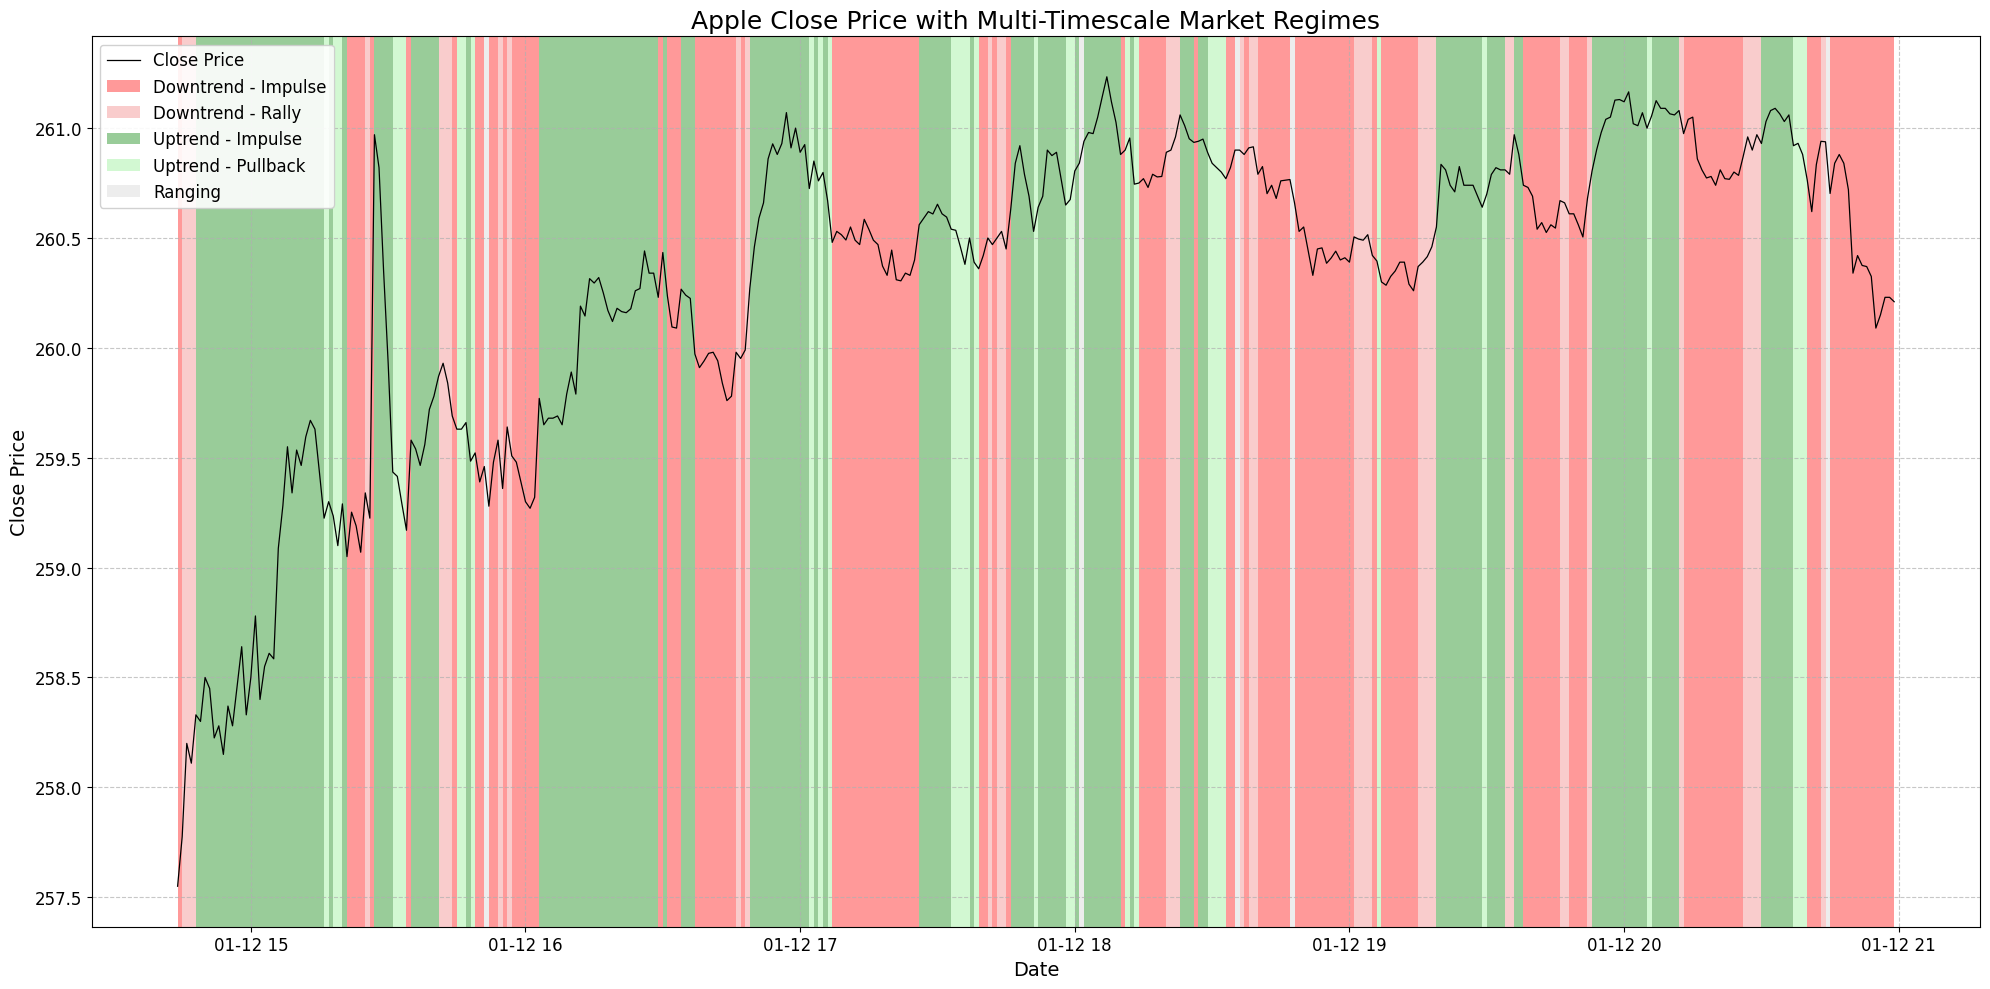

In [18]:
# Drop initial rows with 'Unknown' regime for cleaner visualization
df_plot = market_data_df.dropna(subset=['regime']).copy()
if 'Unknown' in df_plot['regime'].unique():
    df_plot = df_plot[df_plot['regime'] != 'Unknown']

# Define colors for the descriptive regimes
regime_colors = {
    'Uptrend - Impulse': 'green',
    'Uptrend - Pullback': 'lightgreen',
    'Downtrend - Impulse': 'red',
    'Downtrend - Rally': 'lightcoral',
    'Ranging': 'lightgray',
    'Unknown': 'white'
}

plt.figure(figsize=(20, 10))
ax = plt.gca()

# Plot the closing price
ax.plot(df_plot['datetime'], df_plot['close'], color='black', label='Close Price', linewidth=0.9)

# Add colored background spans for each regime
current_regime = None
start_date = None

for index, row in df_plot.iterrows():
    if current_regime is None:
        current_regime = row['regime']
        start_date = row['datetime']
    elif row['regime'] != current_regime:
        end_date = row['datetime']
        
        # Get existing labels to prevent duplicates in legend
        handles, labels = ax.get_legend_handles_labels()
        
        ax.axvspan(
            start_date, 
            end_date, 
            facecolor=regime_colors.get(current_regime, 'white'), 
            alpha=0.4,
            label=current_regime if current_regime not in labels else ""
        )
        current_regime = row['regime']
        start_date = row['datetime']

# Draw the final span
if start_date is not None and current_regime is not None:
    handles, labels = ax.get_legend_handles_labels()
    ax.axvspan(
        start_date, 
        df_plot['datetime'].iloc[-1], 
        facecolor=regime_colors.get(current_regime, 'white'), 
        alpha=0.4,
        label=current_regime if current_regime not in labels else ""
    )

plt.title('Apple Close Price with Multi-Timescale Market Regimes', fontsize=18)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price', fontsize=14)

# Legend configuration: loc='best' keeps it inside, framealpha makes it readable
plt.legend(loc='best', fontsize=12, framealpha=0.9)

plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [19]:
market_data_df.to_parquet(PROCESSED_DATA_FILE, index=False)
print(f"DataFrame with regimes saved to {PROCESSED_DATA_FILE}")

DataFrame with regimes saved to /Users/raoabdul/Documents/Development/Trading-Bot-Algo/data/market_features.parquet
